# 03 - Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the cleaned dataset and understand:

- Distribution of numerical variables
- Distribution of categorical variables
- Outliers
- Target variable distributions
- Correlations between variables
- Relationships between features and health risk scores

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/interim/clean_health_data.csv")

In [3]:
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,145,136,236,6.36,8.18,51.716583,53.581369,50.796020,57.387241,51.492983
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,30,93,150,2.00,5.63,26.096162,47.946740,23.853485,36.219202,3.984993
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,36,118,195,5.07,7.51,54.830087,42.141104,38.977694,42.898797,21.793300
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,140,139,253,5.28,9.03,60.729521,60.286946,53.579555,52.194082,22.962029
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,160,137,184,12.74,7.20,32.778085,15.279074,18.721942,32.095465,34.296907


In [5]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:  97297
Columns:  33


In [6]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297 non-null  

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,121.466407,111.121792,160.014348,9.063591,6.520338,41.237414,41.137170,32.063255,48.407241,26.075076
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,43.393422,13.590382,30.938915,4.956342,0.813710,10.990720,12.755572,15.412755,10.998884,13.028452
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,30.000000,60.000000,70.000000,2.000000,4.000000,1.821211,0.000000,0.000000,12.711686,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,91.000000,102.000000,139.000000,5.090000,5.970000,33.611350,32.136805,20.389335,40.898793,16.506114
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,121.000000,111.000000,160.000000,8.790000,6.520000,40.773364,40.941950,30.793098,48.509658,25.497612
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,151.000000,120.000000,181.000000,12.450000,7.070000,48.430041,49.911238,42.564698,55.928994,34.804830
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,344.000000,172.000000,287.000000,32.220000,9.800000,84.329497,92.102337,97.902483,86.832124,83.112231


In [10]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)


categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'hypertension_risk_score', 'heart_disease_risk_score', 'obesity_risk_score', 'cholesterol_risk_score']

Categorical columns:
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


C:\Users\DELL\AppData\Local\Temp\ipykernel_7920\3138209735.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [ ]:
target_columns = [
    "diabetes_risk_score",
    "hypertension_risk_score",
    "heart_disease_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score"
]

In [15]:
feature_columns = [
    column for column in df.columns
    if column not in target_columns
]

print("No of Feature: ", len(feature_columns))
print("No of Target: ", len(target_columns))

No of Feature:  28
No of Target:  5


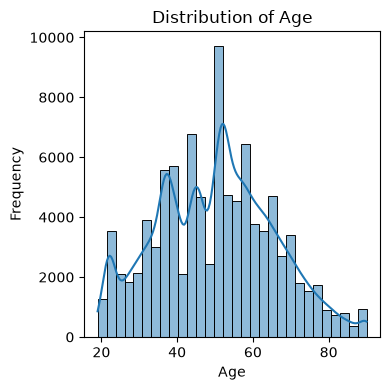

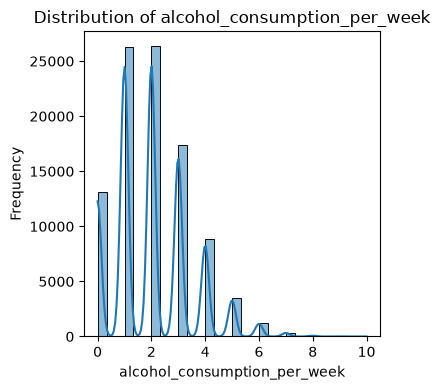

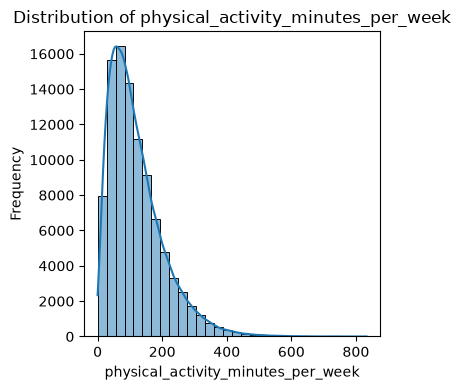

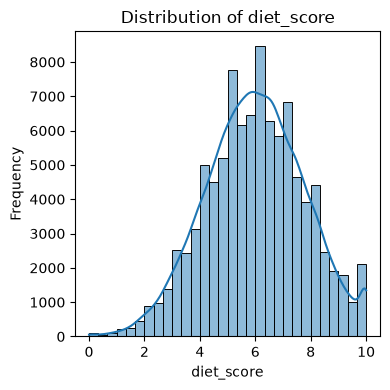

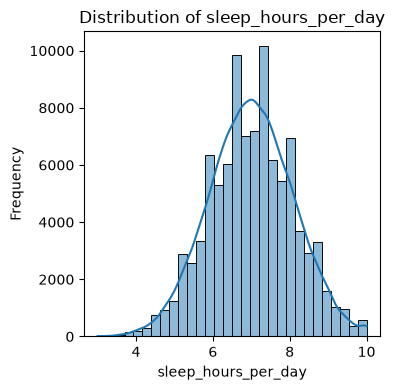

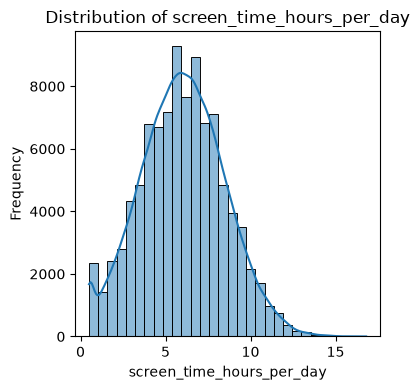

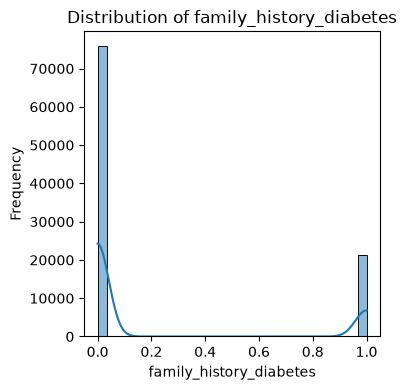

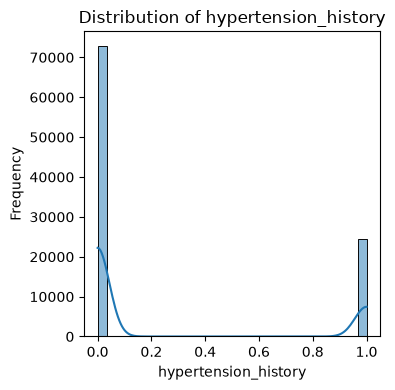

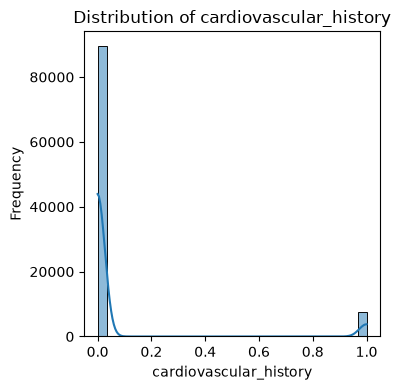

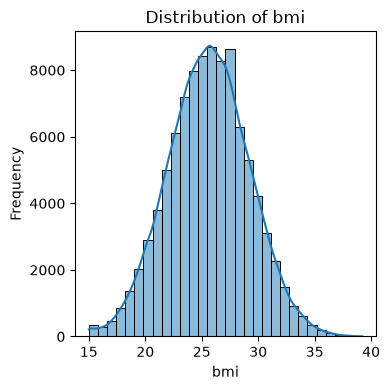

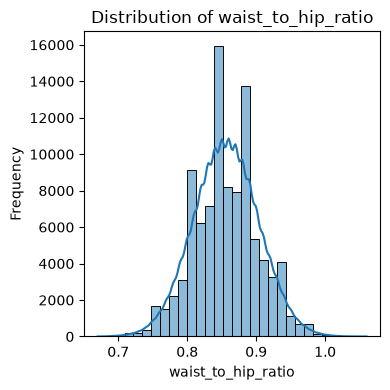

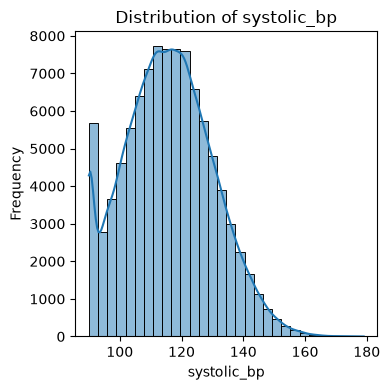

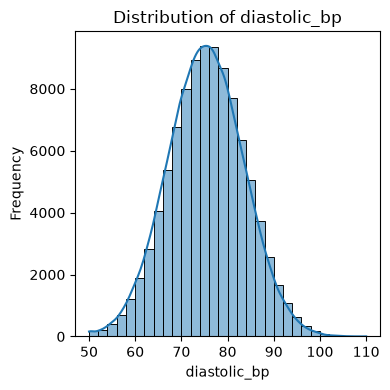

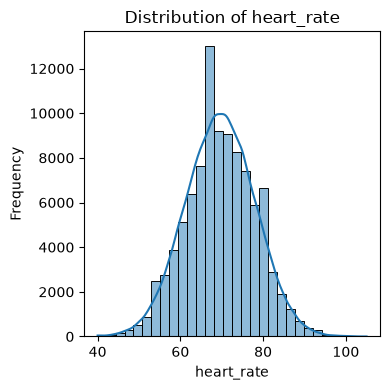

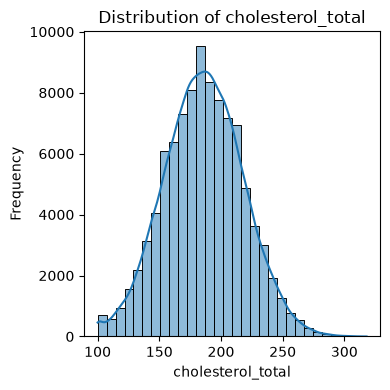

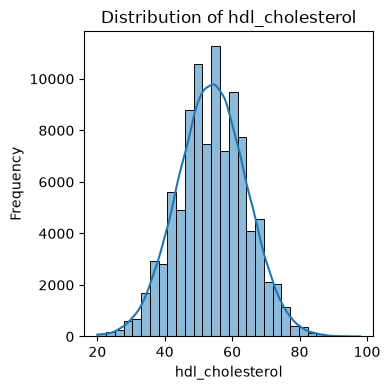

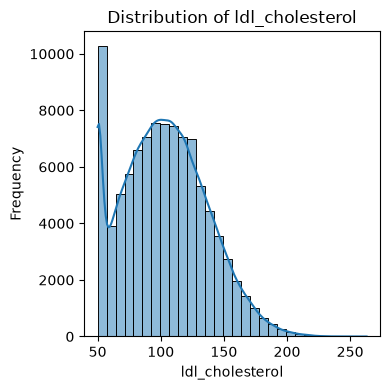

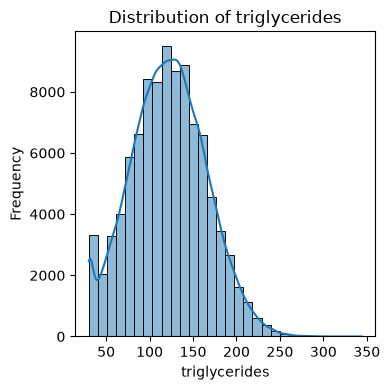

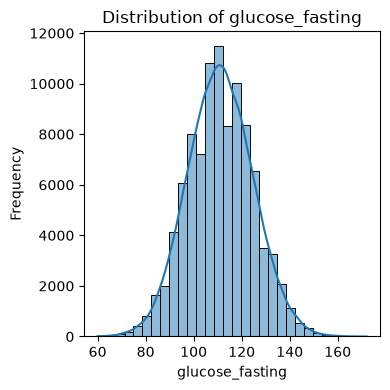

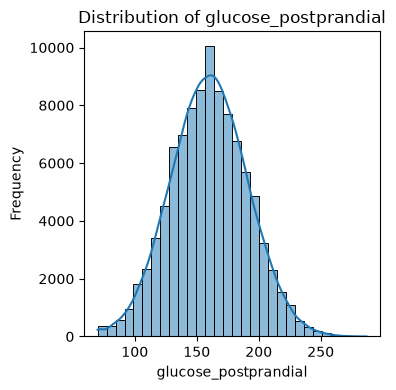

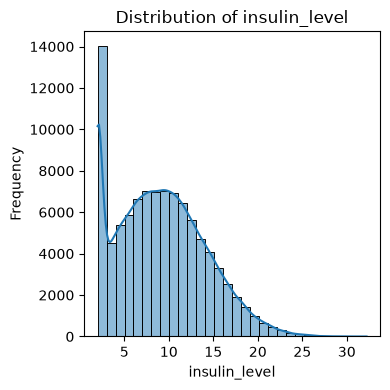

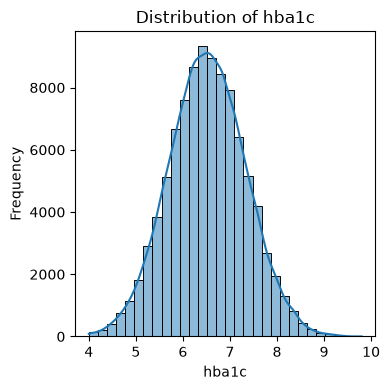

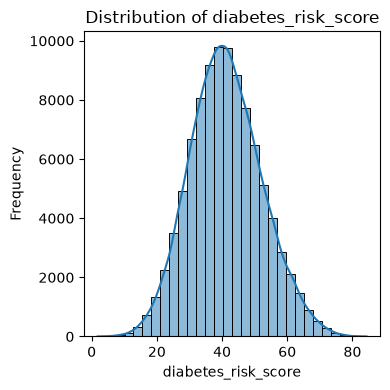

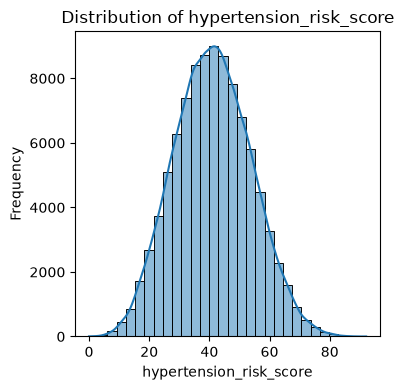

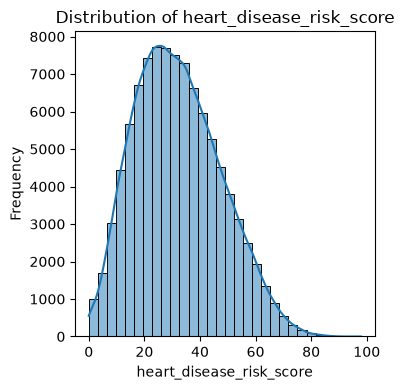

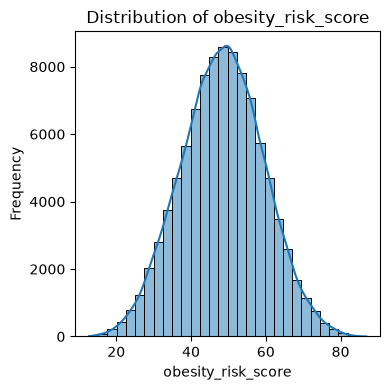

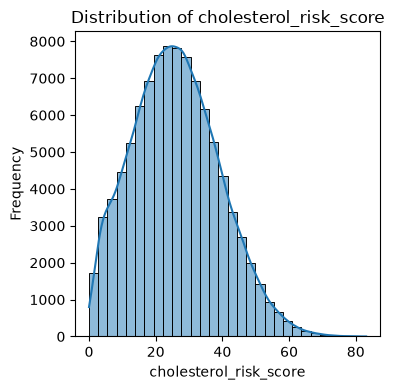

In [17]:
#Histograms for Numerical Variables

for column in numerical_columns:
    
    plt.figure(figsize=(4, 4))
    
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

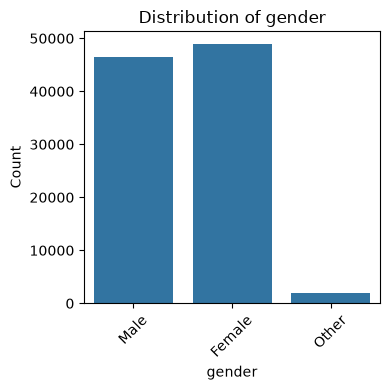

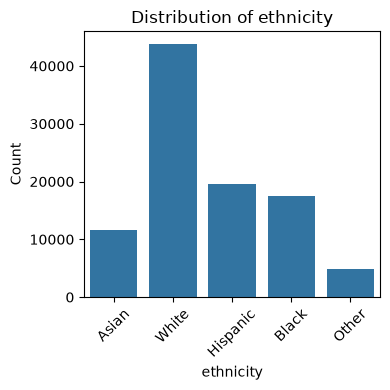

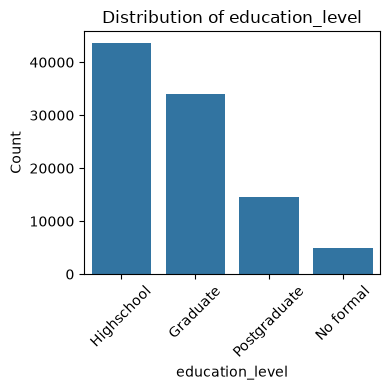

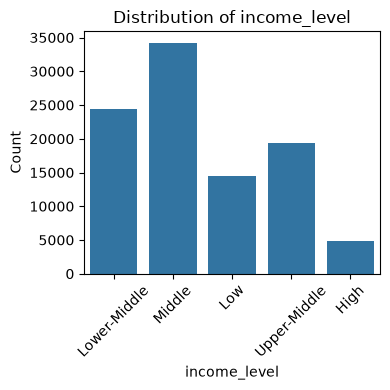

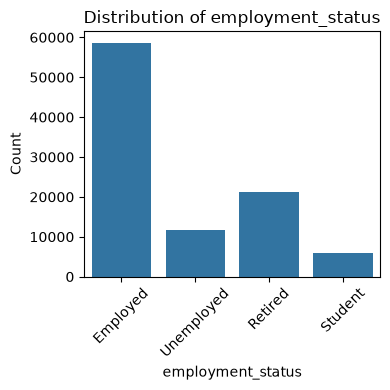

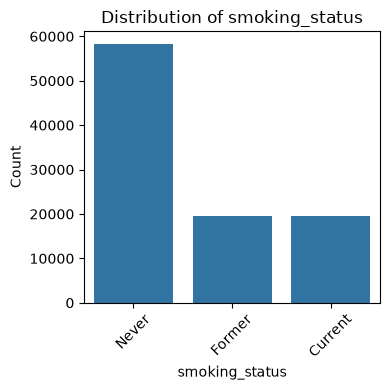

In [25]:
#Categorical Variable Analysis
for column in categorical_columns:
    
    plt.figure(figsize=(4, 4))
    
    sns.countplot(
        data=df,
        x=column
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

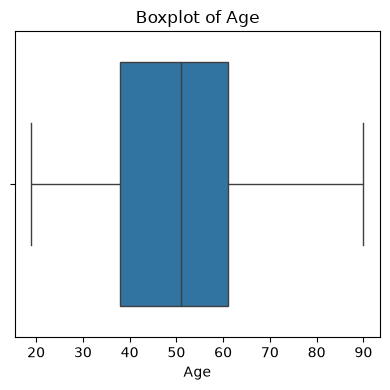

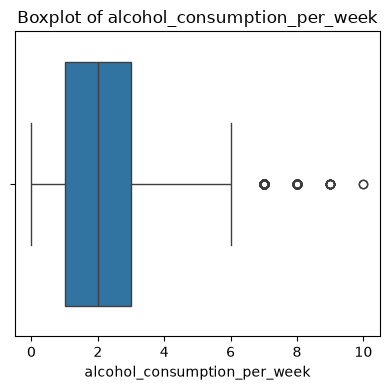

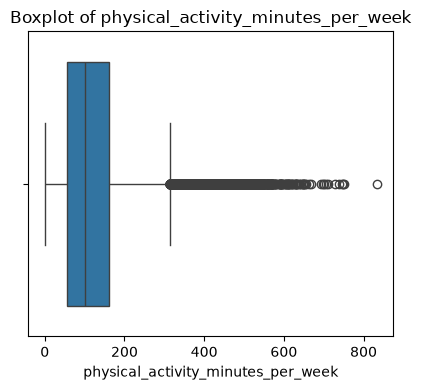

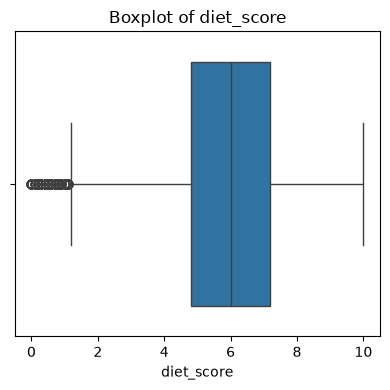

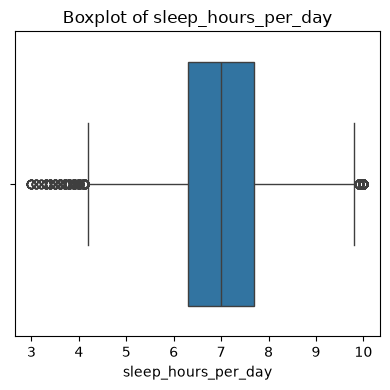

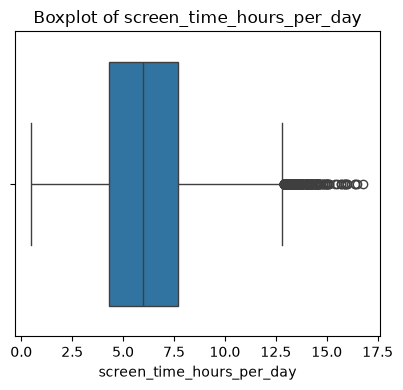

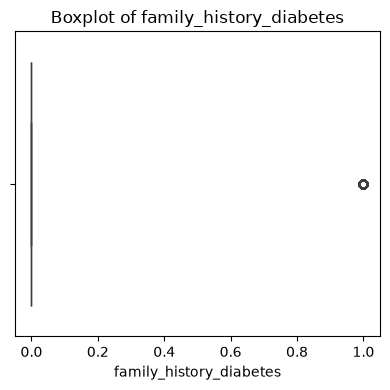

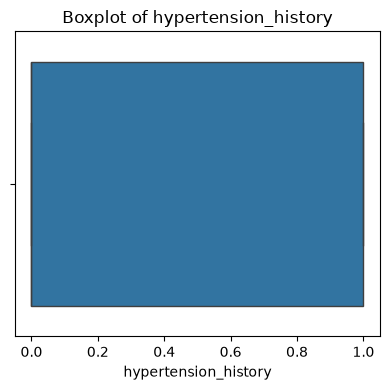

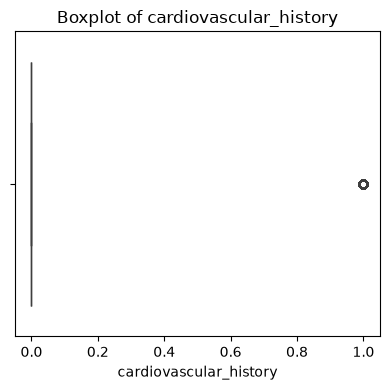

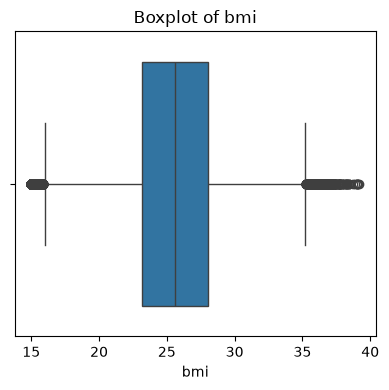

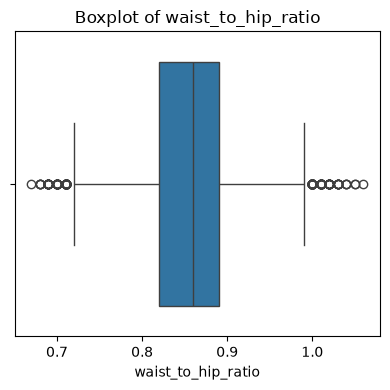

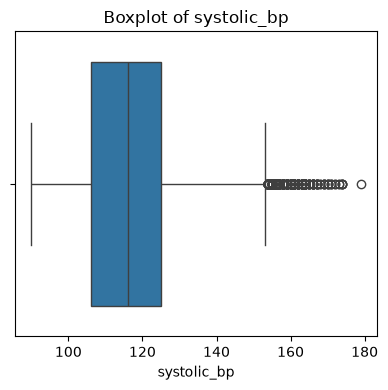

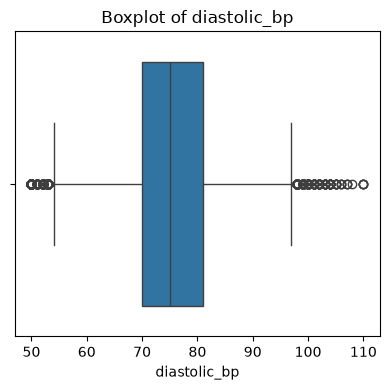

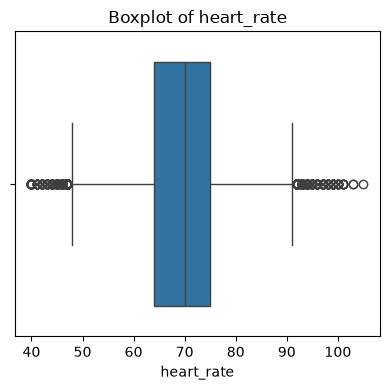

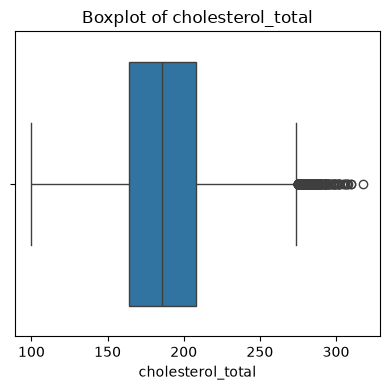

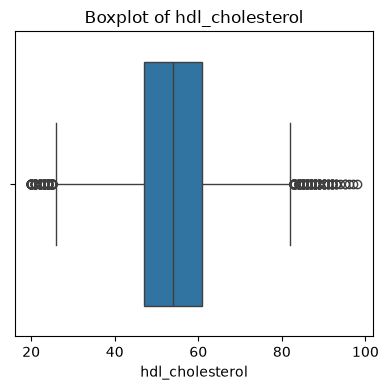

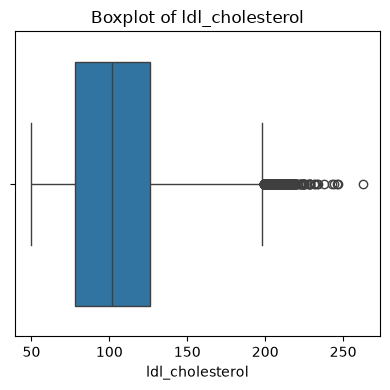

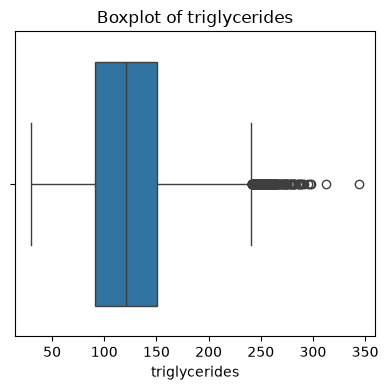

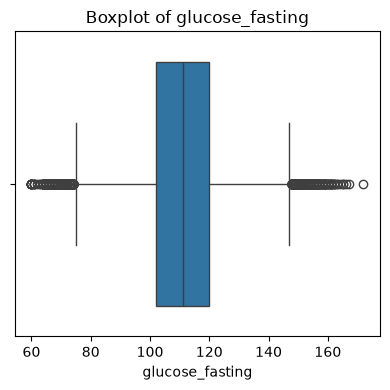

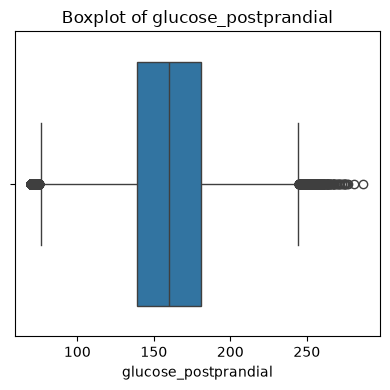

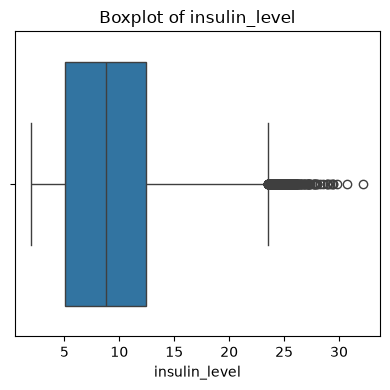

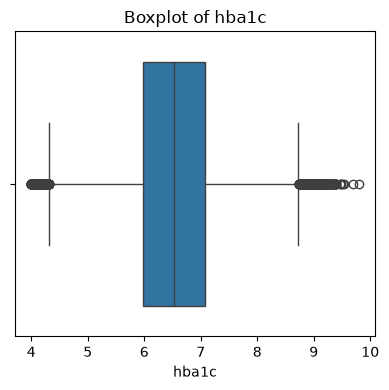

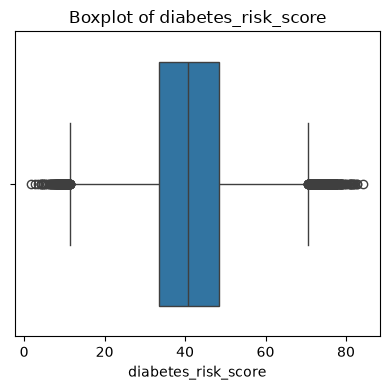

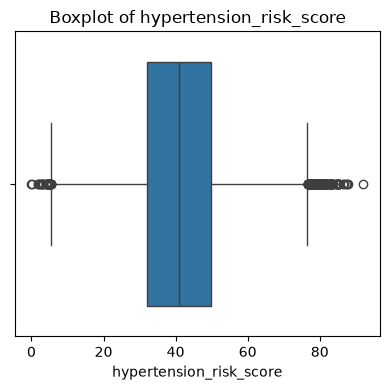

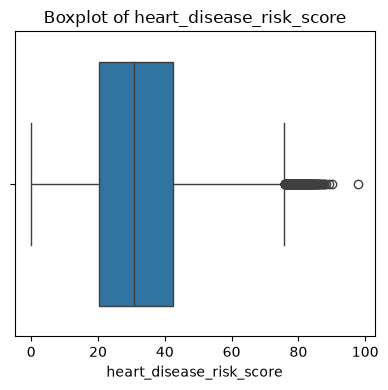

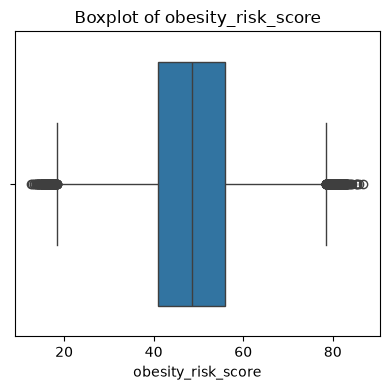

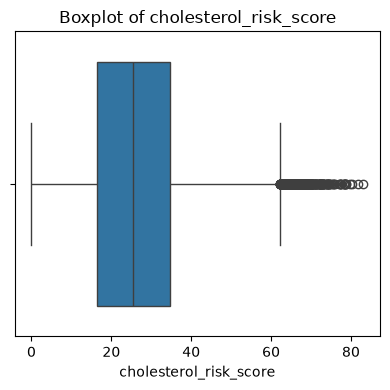

In [26]:
#Outlier Analysis
for column in numerical_columns:
    
    plt.figure(figsize=(4, 4))
    
    sns.boxplot(
        data=df,
        x=column
    )
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [27]:
#Target Variable Analysis

#Summary Statistics
df[target_columns].describe()

,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,41.237414,41.137170,32.063255,48.407241,26.075076
std,10.990720,12.755572,15.412755,10.998884,13.028452
min,1.821211,0.000000,0.000000,12.711686,0.000000
25%,33.611350,32.136805,20.389335,40.898793,16.506114
50%,40.773364,40.941950,30.793098,48.509658,25.497612
75%,48.430041,49.911238,42.564698,55.928994,34.804830
max,84.329497,92.102337,97.902483,86.832124,83.112231


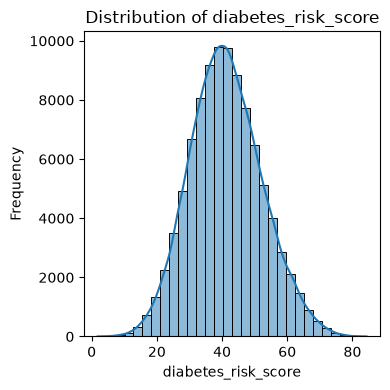

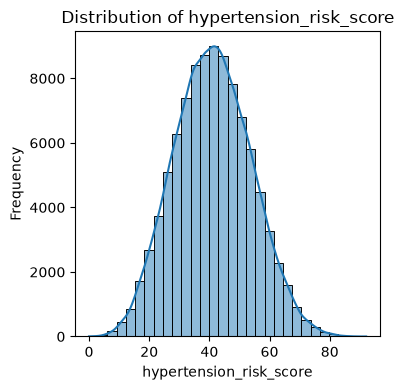

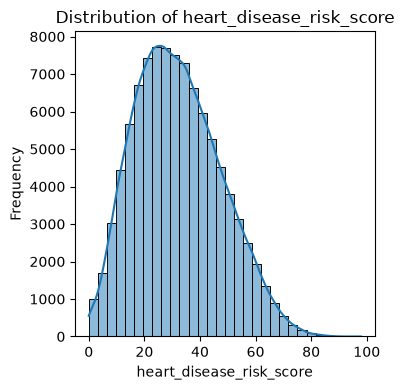

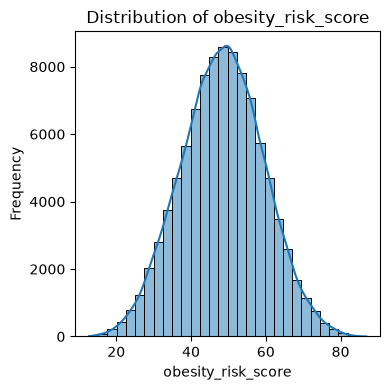

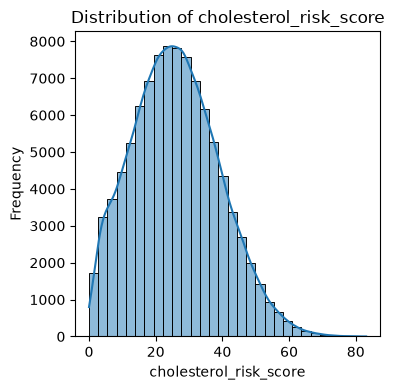

In [29]:
#Histograms of Risk Scores
for column in target_columns:
    
    plt.figure(figsize=(4, 4))
    
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

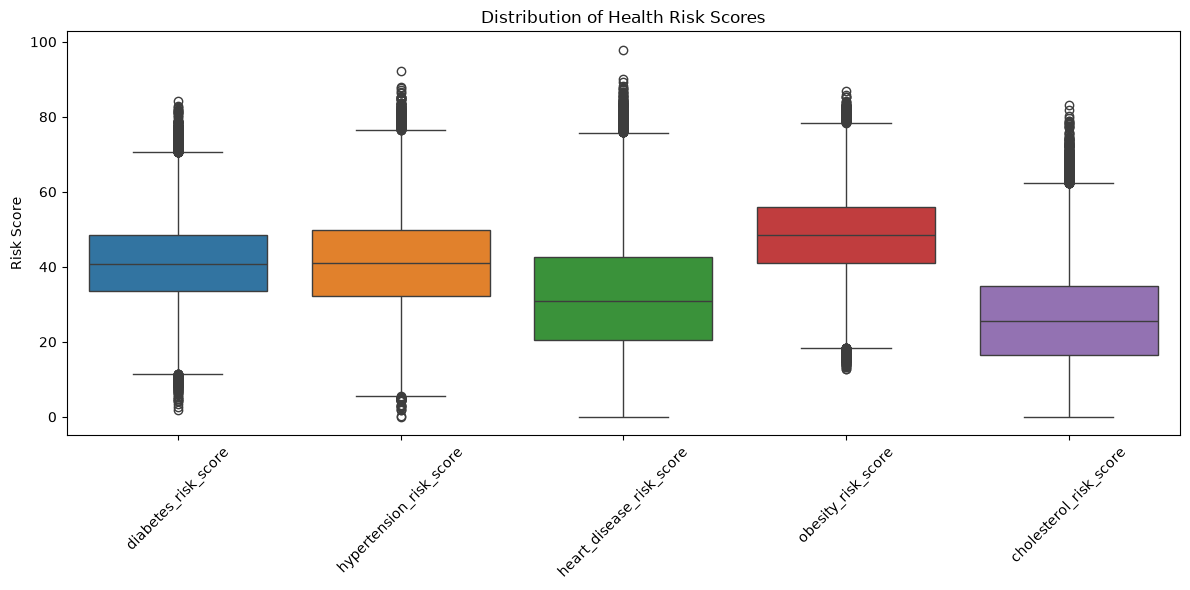

In [30]:
#Target Boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[target_columns]
)

plt.title("Distribution of Health Risk Scores")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#Correlation Analysis

#Calculate Correlation
correlation_matrix = df[numerical_columns].corr()

correlation_matrix


,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
Age,1.000000,0.000774,0.003020,-0.003175,-0.003505,-0.006167,-0.002675,0.177312,0.147476,0.093728,...,0.040028,0.231403,0.132566,0.045420,0.159293,0.414791,0.735870,0.798682,0.080005,0.253711
alcohol_consumption_per_week,0.000774,1.000000,-0.002082,-0.000311,0.001837,0.001794,0.003062,-0.007438,-0.005129,-0.002852,...,0.126534,0.007457,0.005257,0.001075,0.006455,0.007587,-0.001765,0.000942,-0.001563,0.014271
physical_activity_minutes_per_week,0.003020,-0.002082,1.000000,-0.002773,-0.004995,0.001103,-0.006775,-0.000732,0.000003,-0.071631,...,-0.026237,-0.161445,-0.093567,-0.034125,-0.112289,-0.354322,-0.080789,-0.035776,-0.400444,-0.020766
diet_score,-0.003175,-0.000311,-0.002773,1.000000,0.001750,0.003059,0.000448,0.000972,0.004727,-0.201331,...,-0.080170,-0.072204,-0.044979,-0.080781,-0.054412,-0.115852,-0.077401,-0.037355,-0.195800,-0.061508
sleep_hours_per_day,-0.003505,0.001837,-0.004995,0.001750,1.000000,0.004599,0.004008,0.004434,-0.001186,0.000546,...,-0.003513,0.001556,0.000856,-0.000992,0.001577,0.003137,-0.002637,-0.002709,0.002236,0.001983
screen_time_hours_per_day,-0.006167,0.001794,0.001103,0.003059,0.004599,1.000000,-0.002001,-0.002042,-0.000821,-0.003568,...,-0.004595,0.033387,0.020621,0.002066,0.024040,0.006196,-0.006408,-0.002240,0.065911,0.000890
family_history_diabetes,-0.002675,0.003062,-0.006775,0.000448,0.004008,-0.002001,1.000000,0.002434,0.001028,0.000439,...,0.003885,0.345316,0.204973,0.017002,0.242931,0.561887,-0.001910,0.060502,0.003778,0.001346
hypertension_history,0.177312,-0.007438,-0.000732,0.000972,0.004434,-0.002042,0.002434,1.000000,0.023434,0.015342,...,0.009536,0.047572,0.030091,0.009460,0.032938,0.076665,0.132185,0.142361,0.013318,0.042620
cardiovascular_history,0.147476,-0.005129,0.000003,0.004727,-0.001186,-0.000821,0.001028,0.023434,1.000000,0.010483,...,0.009545,0.036630,0.029166,0.009068,0.033320,0.062451,0.107532,0.119702,0.007591,0.036128
bmi,0.093728,-0.002852,-0.071631,-0.201331,0.000546,-0.003568,0.000439,0.015342,0.010483,1.000000,...,0.405606,0.151253,0.092516,0.392163,0.110229,0.554016,0.449071,0.215573,0.905456,0.311652


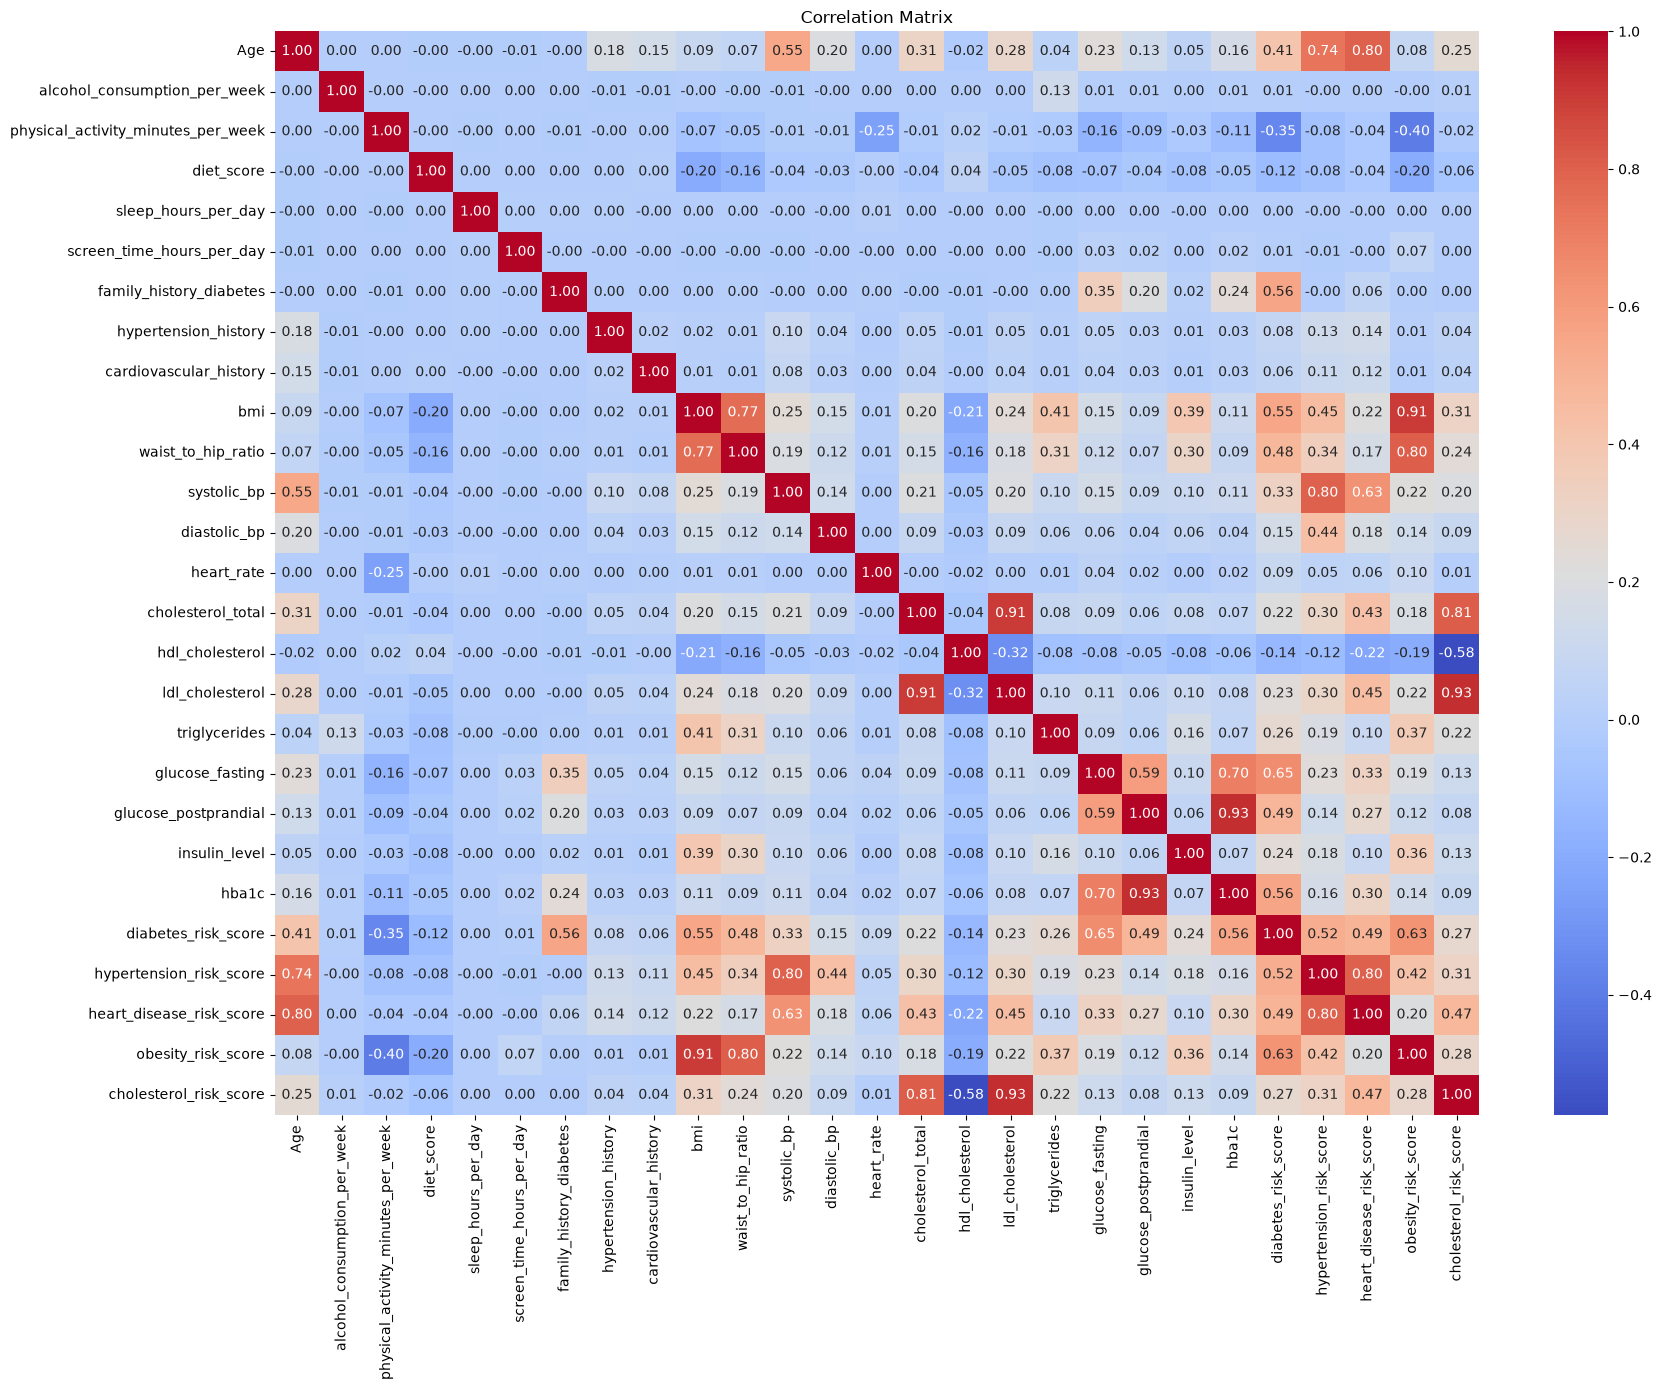

In [32]:
#Correlation Heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [34]:
#Correlation of Features With Targets
target_correlation = correlation_matrix[target_columns]

target_correlation

,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
Age,0.414791,0.735870,0.798682,0.080005,0.253711
alcohol_consumption_per_week,0.007587,-0.001765,0.000942,-0.001563,0.014271
physical_activity_minutes_per_week,-0.354322,-0.080789,-0.035776,-0.400444,-0.020766
diet_score,-0.115852,-0.077401,-0.037355,-0.195800,-0.061508
sleep_hours_per_day,0.003137,-0.002637,-0.002709,0.002236,0.001983
screen_time_hours_per_day,0.006196,-0.006408,-0.002240,0.065911,0.000890
family_history_diabetes,0.561887,-0.001910,0.060502,0.003778,0.001346
hypertension_history,0.076665,0.132185,0.142361,0.013318,0.042620
cardiovascular_history,0.062451,0.107532,0.119702,0.007591,0.036128
bmi,0.554016,0.449071,0.215573,0.905456,0.311652


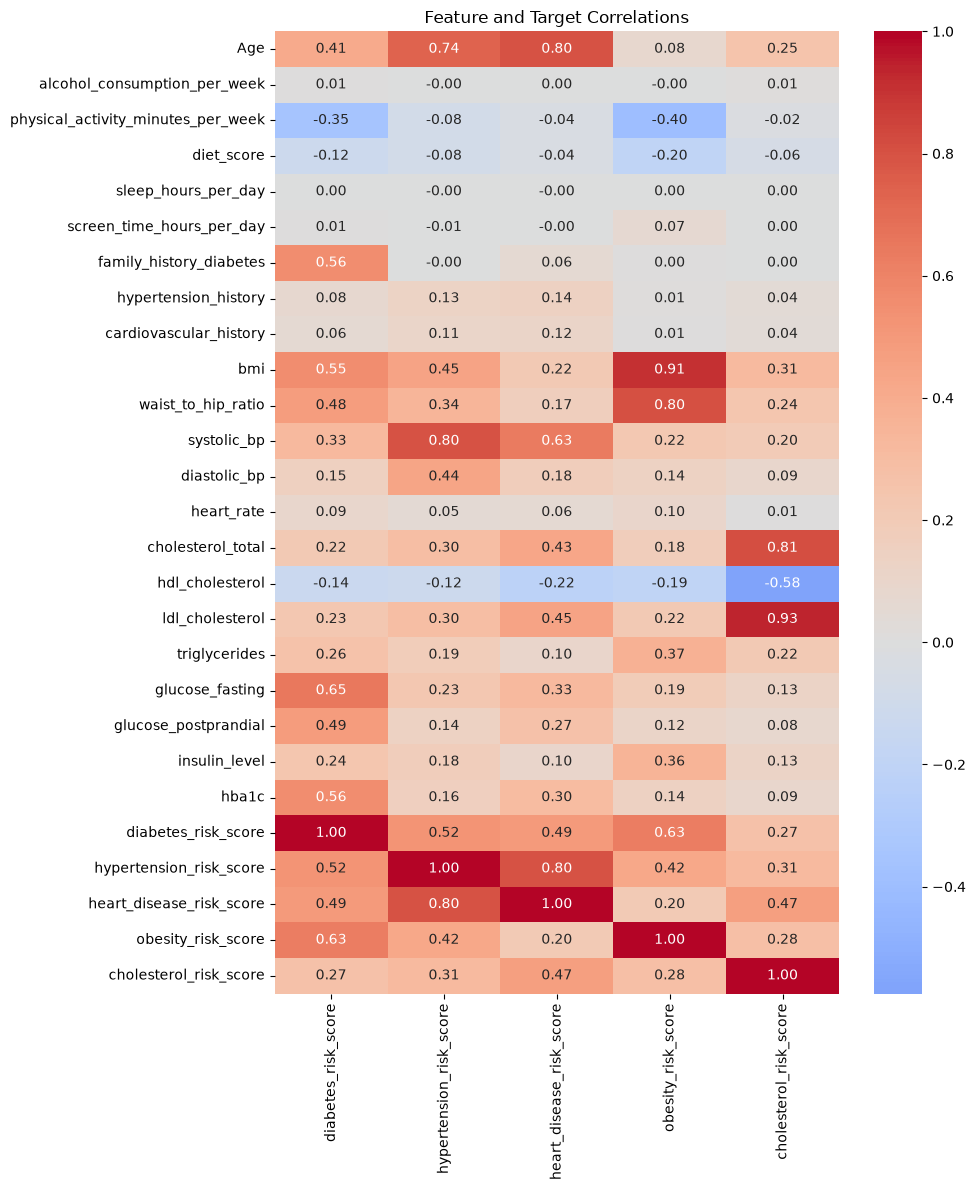

In [35]:
#Visualize Feature-Target Correlation
plt.figure(figsize=(10, 12))

sns.heatmap(
    target_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature and Target Correlations")
plt.tight_layout()
plt.show()

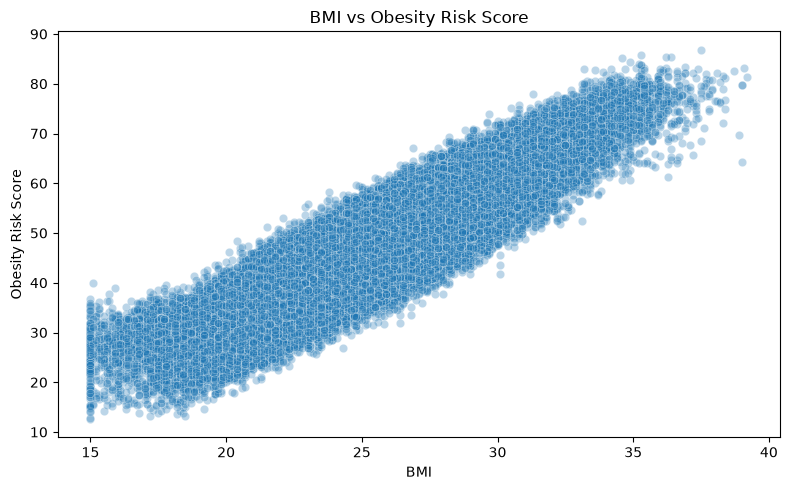

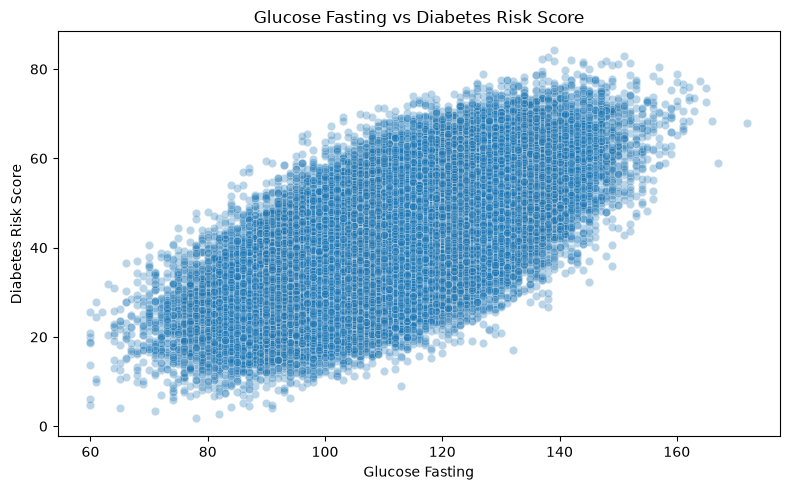

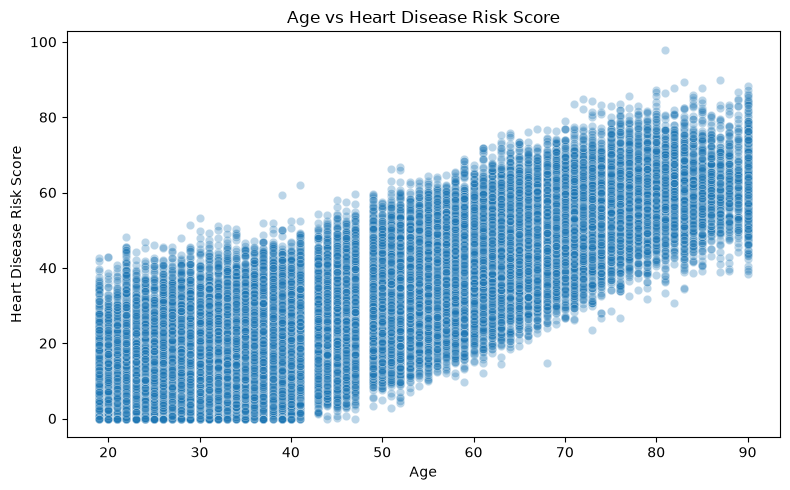

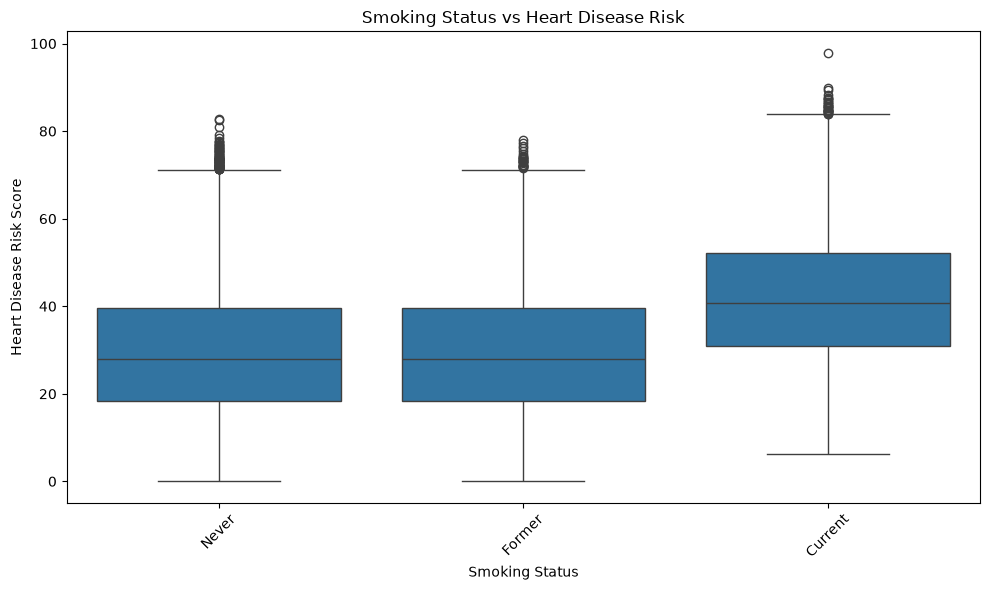

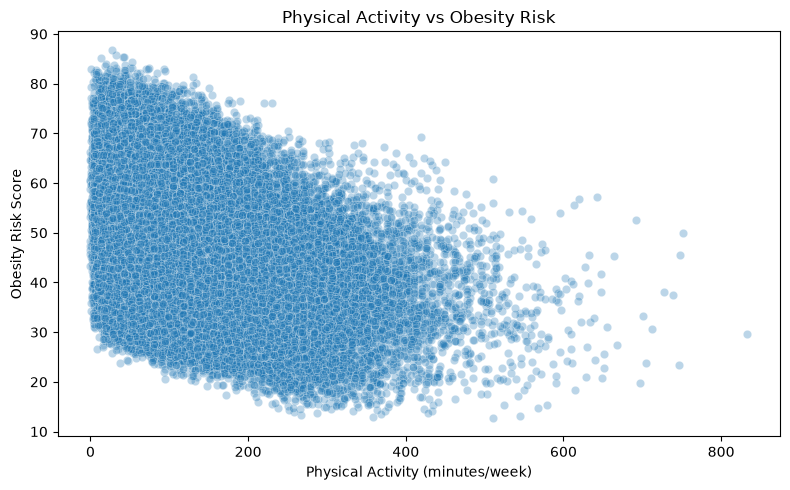

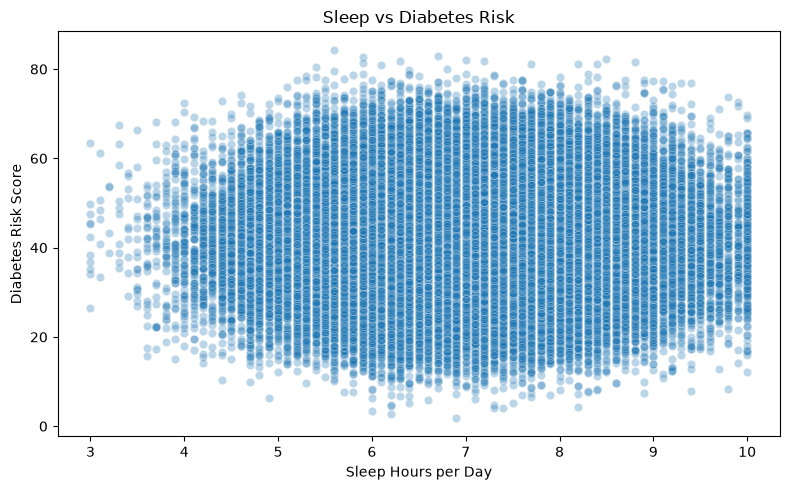

In [42]:
#Feature vs Target Analysis

# 01 - BMI vs Obesity Risk Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="obesity_risk_score",
    alpha=0.3
)

plt.title("BMI vs Obesity Risk Score")
plt.xlabel("BMI")
plt.ylabel("Obesity Risk Score")
plt.tight_layout()
plt.show()

# 02 - Glucose vs Diabetes Risk
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="glucose_fasting",
    y="diabetes_risk_score",
    alpha=0.3
)

plt.title("Glucose Fasting vs Diabetes Risk Score")
plt.xlabel("Glucose Fasting")
plt.ylabel("Diabetes Risk Score")
plt.tight_layout()
plt.show()

#Age vs Heart Disease Risk
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="heart_disease_risk_score",
    alpha=0.3
)

plt.title("Age vs Heart Disease Risk Score")
plt.xlabel("Age")
plt.ylabel("Heart Disease Risk Score")
plt.tight_layout()
plt.show()



#Categorical Variables vs Risk Scores
#Smoking Status vs Heart Disease Risk
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="smoking_status",
    y="heart_disease_risk_score"
)

plt.title("Smoking Status vs Heart Disease Risk")
plt.xlabel("Smoking Status")
plt.ylabel("Heart Disease Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Exercise vs Risk
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="physical_activity_minutes_per_week",
    y="obesity_risk_score",
    alpha=0.3
)

plt.title("Physical Activity vs Obesity Risk")
plt.xlabel("Physical Activity (minutes/week)")
plt.ylabel("Obesity Risk Score")
plt.tight_layout()
plt.show()

#Sleep vs Risk
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sleep_hours_per_day",
    y="diabetes_risk_score",
    alpha=0.3
)

plt.title("Sleep vs Diabetes Risk")
plt.xlabel("Sleep Hours per Day")
plt.ylabel("Diabetes Risk Score")
plt.tight_layout()
plt.show()

# EDA Summary

## Dataset
- Number of observations: 97,297
- Number of columns: 33
- Number of input features: 28
- Number of target variables: 5

## Numerical Variables
The numerical variables were examined using histograms, boxplots, and descriptive statistics.

## Categorical Variables
Categorical variables were examined using frequency counts and bar charts.

## Outliers
Boxplots were used to identify potentially unusual observations. Potential outliers were not automatically removed because unusual health measurements may represent valid observations.

## Target Variables
The distributions of the five health risk scores were examined using histograms and boxplots.

## Correlation
A correlation matrix was created to investigate relationships among numerical variables and between features and target variables.

## Relationships
Scatterplots were used to investigate selected relationships between important health measurements and risk scores.

